## Cell-Type-Aware Similarity: Building GEP Trees Across K Values

Naively correlating all GEPs at K with all GEPs at K+1 can link programs from different cell types. This notebook builds a parent→child GEP tree gated on cell-type identity, using the NES scores produced by notebook 1 (`combined-hnc_k3-35_gsea_celltype_results/`).

**Similarity metric (pick one):**
1. `nes_spearman` — Spearman correlation of NES profile vectors
2. `nes_kl_divergence` — similarity from symmetric KL divergence of NES-derived cell-type distributions, mapped to (0, 1] via exp(−λ·KL)

**Optional family-aware labels:** an ambiguous GEP (no dominant cell type) is normally labeled `Ambiguous/Mixed`. If `CELLTYPE_FAMILIES` is set, a GEP whose top-N cell types all share a family gets that family's label instead (e.g. `Monocyte_family`).

**Output:** an edge list defining the GEP tree across K, plus visualizations.


In [1]:
import os
import glob
import re
import numpy as np
import networkx as nx
from collections import Counter
import pandas as pd
from scipy.stats import spearmanr
from scipy.special import rel_entr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


#### 1. Configuration

In [2]:
# Paths
GSEA_DIR = "hnc_1000hvg-percelltype_clanp_results/k4-20_gsea_celltype_results"  # must match OUTPUT_DIR in notebook 1
OUTPUT_DIR = "hnc_1000hvg-percelltype_clanp_results/k4-20_corr-tree_kl-divergence"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# K range (should match notebook 1)
K_MIN = 4
K_MAX = 20

# Similarity metric: "nes_kl_divergence" (symmetric KL -> similarity via exp(-lambda*KL))
# or "nes_spearman" (Spearman correlation of NES profile vectors)
SIMILARITY_METRIC = "nes_kl_divergence"

# KL divergence parameters (only used when SIMILARITY_METRIC == "nes_kl_divergence")
LAMBDA_KL = 0.5    # steepness of exp(-lambda*KL); higher = stricter
EPSILON = 1e-8     # avoids log(0) in the KL computation

# Minimum similarity to form a parent-child edge (same scale as SIMILARITY_METRIC)
MIN_SIMILARITY = 0.3

# Dominance cutoff for assigning a single top cell type: (p1-p2)/p1 must be >= this.
# 0.0 disables ambiguity detection (always top-1); 1.0 requires p2 == 0.
AMBIGUITY_THRESHOLD = 0.15

# Optional: map families -> cell types. An ambiguous GEP whose top FAMILY_CHECK_TOP_N
# cell types all belong to one family gets that family's label instead of "Ambiguous/Mixed".
# Set to None to disable.
CELLTYPE_FAMILIES = {
    "Monocyte":   ["Mono_CD14", "Mono_CD14_ID1", "Mono_CD14_IL1B", "Mono_CD14_THBS1",
                   "Mono_CD16", "Mono_Int", "Mono_TIL"],
    "DC":         ["cDC1_CLEC9A", "cDC2_CD1C", "cDC2_CD33", "mregDC_LAMP3"],
    "Macrophage": ["Mac_CXCL9", "Mac_IL1B", "Mac_IL1Bint", "Mac_SPP1"],
}
FAMILY_CHECK_TOP_N = 3
FAMILY_LABEL_SUFFIX = "_family"

In [3]:
print(f"Similarity metric: {SIMILARITY_METRIC}")
if SIMILARITY_METRIC == "nes_kl_divergence":
    print(f"  Lambda (KL mapping): {LAMBDA_KL}")
    print(f"  Epsilon: {EPSILON}")
print(f"Min similarity threshold: {MIN_SIMILARITY}")
print(f"Ambiguity threshold: {AMBIGUITY_THRESHOLD}")
print(f"K range: {K_MIN}–{K_MAX}")

if CELLTYPE_FAMILIES is None:
    print("Hierarchical families: DISABLED (no family-level labels will be produced)")
else:
    print(f"Hierarchical families: ENABLED ({len(CELLTYPE_FAMILIES)} families)")
    for fam, cts in CELLTYPE_FAMILIES.items():
        print(f"  {fam}{FAMILY_LABEL_SUFFIX}: {len(cts)} cell types → {cts}")
    print(f"  Top-N check: top {FAMILY_CHECK_TOP_N} cell types must all be in the same family")

Similarity metric: nes_kl_divergence
  Lambda (KL mapping): 0.5
  Epsilon: 1e-08
Min similarity threshold: 0.3
Ambiguity threshold: 0.15
K range: 4–20
Hierarchical families: ENABLED (3 families)
  Monocyte_family: 7 cell types → ['Mono_CD14', 'Mono_CD14_ID1', 'Mono_CD14_IL1B', 'Mono_CD14_THBS1', 'Mono_CD16', 'Mono_Int', 'Mono_TIL']
  DC_family: 4 cell types → ['cDC1_CLEC9A', 'cDC2_CD1C', 'cDC2_CD33', 'mregDC_LAMP3']
  Macrophage_family: 4 cell types → ['Mac_CXCL9', 'Mac_IL1B', 'Mac_IL1Bint', 'Mac_SPP1']
  Top-N check: top 3 cell types must all be in the same family


#### 2. Load NES Scores

In [4]:
all_nes = {}   # k -> DataFrame (GEPs × cell types)
k_values = []

for f in sorted(glob.glob(os.path.join(GSEA_DIR, "NES_k*.csv"))):
    match = re.search(r'NES_k(\d+)\.csv', os.path.basename(f))
    if match:
        k = int(match.group(1))
        if K_MIN <= k <= K_MAX:
            df = pd.read_csv(f, index_col=0)
            all_nes[k] = df
            k_values.append(k)

k_values = sorted(k_values)
print(f"Loaded NES for {len(k_values)} K values: {k_values}")
for k in k_values:
    print(f"  K={k}: {all_nes[k].shape[0]} GEPs × {all_nes[k].shape[1]} cell types")

Loaded NES for 17 K values: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
  K=4: 4 GEPs × 17 cell types
  K=5: 5 GEPs × 17 cell types
  K=6: 6 GEPs × 17 cell types
  K=7: 7 GEPs × 17 cell types
  K=8: 8 GEPs × 17 cell types
  K=9: 9 GEPs × 17 cell types
  K=10: 10 GEPs × 17 cell types
  K=11: 11 GEPs × 17 cell types
  K=12: 12 GEPs × 17 cell types
  K=13: 13 GEPs × 17 cell types
  K=14: 14 GEPs × 17 cell types
  K=15: 15 GEPs × 17 cell types
  K=16: 16 GEPs × 17 cell types
  K=17: 17 GEPs × 17 cell types
  K=18: 18 GEPs × 17 cell types
  K=19: 19 GEPs × 17 cell types
  K=20: 20 GEPs × 17 cell types


#### 3. Helper Functions

In [5]:
def nes_to_distribution(nes_row, epsilon=EPSILON):
    """NES scores -> probability distribution: ReLU (keep positive enrichment only), then normalize."""
    vals = np.maximum(nes_row.values.astype(float), 0.0)
    if vals.sum() == 0:
        return np.ones(len(vals)) / len(vals)
    dist = vals / vals.sum()
    dist = dist + epsilon
    dist = dist / dist.sum()
    return dist


def _build_ct_to_family(celltype_families):
    """Invert family -> [cell types] into {cell type: family}. None if families are disabled."""
    if celltype_families is None:
        return None
    mapping = {}
    for fam, cts in celltype_families.items():
        for ct in cts:
            if ct in mapping and mapping[ct] != fam:
                raise ValueError(
                    f"Cell type '{ct}' appears in multiple families "
                    f"('{mapping[ct]}' and '{fam}'). Families must be disjoint."
                )
            mapping[ct] = fam
    return mapping


def is_family_label(label, family_label_suffix=FAMILY_LABEL_SUFFIX,
                    celltype_families=CELLTYPE_FAMILIES):
    """True if `label` is a family-level label produced by assign_celltype."""
    if celltype_families is None or not label.endswith(family_label_suffix):
        return False
    family_name = label[:-len(family_label_suffix)] if family_label_suffix else label
    return family_name in celltype_families


def assign_celltype(nes_row,
                    epsilon=EPSILON,
                    ambiguity_threshold=AMBIGUITY_THRESHOLD,
                    celltype_families=CELLTYPE_FAMILIES,
                    family_check_top_n=FAMILY_CHECK_TOP_N,
                    family_label_suffix=FAMILY_LABEL_SUFFIX):
    """
    Assign a cell-type label to a GEP.
      1. Convert NES -> probability distribution.
      2. If the top cell type dominates ((p1-p2)/p1 >= ambiguity_threshold), return it.
      3. Otherwise, if the top-N cell types all share a family, return "<family>_family".
      4. Otherwise return "Ambiguous/Mixed".
    """
    dist = nes_to_distribution(nes_row, epsilon)
    dist_series = pd.Series(dist, index=nes_row.index)
    ranked = dist_series.sort_values(ascending=False)

    top1_ct = ranked.index[0]
    top1_prob = ranked.iloc[0]

    if len(ranked) < 2 or top1_prob == 0:
        return top1_ct

    top2_prob = ranked.iloc[1]
    dominance = (top1_prob - top2_prob) / top1_prob

    if dominance >= ambiguity_threshold:
        return top1_ct

    if celltype_families is not None:
        ct_to_family = _build_ct_to_family(celltype_families)
        top_n = min(family_check_top_n, len(ranked))
        top_cts = list(ranked.index[:top_n])
        top_families = [ct_to_family.get(ct, None) for ct in top_cts]

        first_fam = top_families[0]
        if first_fam is not None and all(f == first_fam for f in top_families):
            return f"{first_fam}{family_label_suffix}"

    return "Ambiguous/Mixed"


def symmetric_kl(p, q):
    """Symmetric KL divergence: 0.5 * (KL(P||Q) + KL(Q||P))."""
    return 0.5 * (np.sum(rel_entr(p, q)) + np.sum(rel_entr(q, p)))


def compute_similarity(nes_parent, nes_child,
                       metric="nes_spearman",
                       lambda_kl=LAMBDA_KL, epsilon=EPSILON):
    """Similarity between a parent and child GEP's NES profiles, under the chosen metric."""
    common_ct = nes_parent.index.intersection(nes_child.index)
    p_aligned = nes_parent[common_ct]
    c_aligned = nes_child[common_ct]

    parent_ct = assign_celltype(p_aligned)
    child_ct = assign_celltype(c_aligned)
    ct_match = (parent_ct == child_ct)

    if metric == "nes_spearman":
        if len(common_ct) < 3:
            sim = 0.0
            raw = 0.0
        else:
            rho, _ = spearmanr(p_aligned.values, c_aligned.values)
            rho = rho if not np.isnan(rho) else 0.0
            sim = rho
            raw = rho

    elif metric == "nes_kl_divergence":
        p_dist = nes_to_distribution(p_aligned, epsilon)
        c_dist = nes_to_distribution(c_aligned, epsilon)
        kl = symmetric_kl(p_dist, c_dist)
        sim = np.exp(-lambda_kl * kl)
        raw = kl

    else:
        raise ValueError(f"Unknown metric: {metric}")

    return {
        'similarity': sim,
        'raw_value': raw,
        'parent_celltype': parent_ct,
        'child_celltype': child_ct,
        'celltype_match': ct_match
    }


#### 3.5. Track Family-Level Label Assignments

For every GEP where `assign_celltype` returns a family label (e.g. `Monocyte_family`), record the event and its top-N cell types to `family_label_assignments.tsv` in `OUTPUT_DIR`. Skipped when `CELLTYPE_FAMILIES is None`.


In [6]:
family_label_rows = []

if CELLTYPE_FAMILIES is not None:
    for k in k_values:
        nes_k = all_nes[k]   # rows = GEPs, cols = cell types
        for gep in nes_k.index:
            nes_row = nes_k.loc[gep]
            label = assign_celltype(nes_row)

            if not is_family_label(label):
                continue

            # Recover the top-N cell types in ranked order (same ranking
            # used inside assign_celltype).
            dist = nes_to_distribution(nes_row)
            ranked = (pd.Series(dist, index=nes_row.index)
                        .sort_values(ascending=False))
            top_n = min(FAMILY_CHECK_TOP_N, len(ranked))
            top_cts = list(ranked.index[:top_n])

            row = {
                'k': k,
                'gep': gep,
                'family_label': label,
            }
            for i, ct in enumerate(top_cts, start=1):
                row[f'top{i}_celltype'] = ct
            family_label_rows.append(row)

    family_label_df = pd.DataFrame(family_label_rows)
    out_path = os.path.join(OUTPUT_DIR, 'family_label_assignments.tsv')
    family_label_df.to_csv(out_path, sep='\t', index=False)

    n_k = family_label_df['k'].nunique() if len(family_label_df) else 0
    print(f"Family-label assignments: {len(family_label_df)} GEPs tracked "
          f"across {n_k} K values")
    print(f"Saved → {out_path}")

    if len(family_label_df) > 0:
        print("\nCounts per family label:")
        print(family_label_df['family_label'].value_counts().to_string())
        print("\nFirst rows:")
        print(family_label_df.head(10).to_string(index=False))
else:
    family_label_df = pd.DataFrame()
    print("CELLTYPE_FAMILIES is None — skipping family-label tracking.")

Family-label assignments: 53 GEPs tracked across 17 K values
Saved → hnc_1000hvg-percelltype_clanp_results/k4-20_corr-tree_kl-divergence/family_label_assignments.tsv

Counts per family label:
family_label
DC_family            31
Macrophage_family    22

First rows:
 k  gep      family_label top1_celltype top2_celltype top3_celltype
 4    2 Macrophage_family     Mac_CXCL9      Mac_SPP1   Mac_IL1Bint
 4    3         DC_family  mregDC_LAMP3     cDC2_CD1C   cDC1_CLEC9A
 5    2 Macrophage_family     Mac_CXCL9      Mac_SPP1   Mac_IL1Bint
 5    3         DC_family  mregDC_LAMP3     cDC2_CD1C   cDC1_CLEC9A
 6    2 Macrophage_family     Mac_CXCL9      Mac_SPP1   Mac_IL1Bint
 6    3         DC_family  mregDC_LAMP3     cDC2_CD1C   cDC1_CLEC9A
 7    2 Macrophage_family     Mac_CXCL9      Mac_SPP1   Mac_IL1Bint
 7    6         DC_family  mregDC_LAMP3     cDC2_CD1C   cDC1_CLEC9A
 8    5         DC_family  mregDC_LAMP3     cDC2_CD1C   cDC1_CLEC9A
 9    5         DC_family  mregDC_LAMP3     cDC2_CD1C 

#### 3.6. Per-GEP final label table

Every (K, GEP) with the label `assign_celltype` actually returns, written to `per_gep_labels.tsv` in `OUTPUT_DIR`. Downstream notebooks (e.g. `4_rogue_per_gep_audit.ipynb`) join against this table.


In [7]:
per_gep_label_rows = []
for k in k_values:
    nes_k = all_nes[k]
    for gep in nes_k.index:
        per_gep_label_rows.append({
            'k':     k,
            'gep':   str(gep),
            'label': assign_celltype(nes_k.loc[gep]),
        })

per_gep_label_df = pd.DataFrame(per_gep_label_rows)
per_gep_label_path = os.path.join(OUTPUT_DIR, 'per_gep_labels.tsv')
per_gep_label_df.to_csv(per_gep_label_path, sep='\t', index=False)

print(f"Per-GEP label table: {len(per_gep_label_df)} rows "
      f"across {per_gep_label_df['k'].nunique()} K values")
print(f"Saved → {per_gep_label_path}")

label_summary = per_gep_label_df['label'].value_counts()
print("\nLabel counts (across all K):")
print(label_summary.to_string())

Per-GEP label table: 204 rows across 17 K values
Saved → hnc_1000hvg-percelltype_clanp_results/k4-20_corr-tree_kl-divergence/per_gep_labels.tsv

Label counts (across all K):
label
Ambiguous/Mixed      111
DC_family             31
Macrophage_family     22
Mono_CD16             11
Mast                  10
Mono_CD14_ID1          9
DC_pDC                 8
Mac_SPP1               1
Mono_CD14_THBS1        1


#### 4. Compute All Pairwise Similarities Across Consecutive K Values

In [8]:
# For each consecutive (K, K+1) pair, compute the full similarity matrix
# between all parent GEPs at K and all child GEPs at K+1.

all_sim_matrices = {}   # (k_parent, k_child) -> DataFrame
all_detail_records = [] # list of dicts for detailed inspection

for i in range(len(k_values) - 1):
    k_parent = k_values[i]
    k_child = k_values[i + 1]

    nes_p = all_nes[k_parent]
    nes_c = all_nes[k_child]

    sim_matrix = pd.DataFrame(
        index=nes_p.index,
        columns=nes_c.index,
        dtype=float
    )

    for parent_gep in nes_p.index:
        for child_gep in nes_c.index:
            result = compute_similarity(
                nes_parent=nes_p.loc[parent_gep],
                nes_child=nes_c.loc[child_gep],
                metric=SIMILARITY_METRIC,
                lambda_kl=LAMBDA_KL,
                epsilon=EPSILON
            )

            sim_matrix.loc[parent_gep, child_gep] = result['similarity']

            all_detail_records.append({
                'k_parent': k_parent,
                'k_child': k_child,
                'parent_gep': parent_gep,
                'child_gep': child_gep,
                'similarity': result['similarity'],
                'raw_value': result['raw_value'],
                'parent_celltype': result['parent_celltype'],
                'child_celltype': result['child_celltype'],
                'celltype_match': result['celltype_match']
            })

    all_sim_matrices[(k_parent, k_child)] = sim_matrix

    print(f"K={k_parent} → K={k_child}: "
          f"{sim_matrix.shape[0]} parents × {sim_matrix.shape[1]} children, "
          f"max similarity = {sim_matrix.values.max():.3f}")

details_df = pd.DataFrame(all_detail_records)
print(f"\nTotal pairwise comparisons: {len(details_df)}")

K=4 → K=5: 4 parents × 5 children, max similarity = 1.000
K=5 → K=6: 5 parents × 6 children, max similarity = 1.000
K=6 → K=7: 6 parents × 7 children, max similarity = 1.000
K=7 → K=8: 7 parents × 8 children, max similarity = 1.000
K=8 → K=9: 8 parents × 9 children, max similarity = 1.000
K=9 → K=10: 9 parents × 10 children, max similarity = 1.000
K=10 → K=11: 10 parents × 11 children, max similarity = 1.000
K=11 → K=12: 11 parents × 12 children, max similarity = 1.000
K=12 → K=13: 12 parents × 13 children, max similarity = 1.000
K=13 → K=14: 13 parents × 14 children, max similarity = 1.000
K=14 → K=15: 14 parents × 15 children, max similarity = 1.000
K=15 → K=16: 15 parents × 16 children, max similarity = 1.000
K=16 → K=17: 16 parents × 17 children, max similarity = 1.000
K=17 → K=18: 17 parents × 18 children, max similarity = 1.000
K=18 → K=19: 18 parents × 19 children, max similarity = 1.000
K=19 → K=20: 19 parents × 20 children, max similarity = 1.000

Total pairwise comparisons: 2

#### 5. Build the Edge List (Parent → Child Assignments)

**Strategy:** For each child GEP at K+1, assign the best parent at K (greedy best-match-per-child). A parent can have 0, 1, or many children (supporting splits). Children with no parent above `MIN_SIMILARITY` are flagged as "novel" (de novo emergence).

In [9]:
edges = []

for (k_parent, k_child), sim_matrix in sorted(all_sim_matrices.items()):
    for child_gep in sim_matrix.columns:
        best_parent = sim_matrix[child_gep].idxmax()
        best_sim = sim_matrix[child_gep].max()

        if best_sim >= MIN_SIMILARITY:
            parent_ct = assign_celltype(all_nes[k_parent].loc[best_parent])
            child_ct = assign_celltype(all_nes[k_child].loc[child_gep])

            edges.append({
                'k_parent': k_parent,
                'k_child': k_child,
                'parent_gep': best_parent,
                'child_gep': child_gep,
                'similarity': round(best_sim, 4),
                'parent_celltype': parent_ct,
                'child_celltype': child_ct,
                'celltype_match': parent_ct == child_ct
            })
        else:
            child_ct = assign_celltype(all_nes[k_child].loc[child_gep])
            edges.append({
                'k_parent': k_parent,
                'k_child': k_child,
                'parent_gep': None,
                'child_gep': child_gep,
                'similarity': round(best_sim, 4),
                'parent_celltype': None,
                'child_celltype': child_ct,
                'celltype_match': False
            })

edges_df = pd.DataFrame(edges)

n_connected = edges_df['parent_gep'].notna().sum()
n_novel = edges_df['parent_gep'].isna().sum()
n_ct_match = edges_df.loc[edges_df['parent_gep'].notna(), 'celltype_match'].sum()

print(f"Total edges: {len(edges_df)}")
print(f"  Connected (parent assigned): {n_connected}")
print(f"  Novel (no parent above threshold): {n_novel}")
print(f"  Cell-type-matching edges: {n_ct_match}/{n_connected} "
      f"({100*n_ct_match/max(n_connected,1):.1f}%)")

Total edges: 200
  Connected (parent assigned): 199
  Novel (no parent above threshold): 1
  Cell-type-matching edges: 157/199 (78.9%)


#### 6. Identify Splits and Merges

- **Split:** A parent at K maps to 2+ children at K+1
- **Merge:** A child at K+1 is the best match for 2+ parents at K (rare with best-match-per-child, but detectable)

In [10]:
connected_edges = edges_df[edges_df['parent_gep'].notna()].copy()

# Splits: parents with multiple children
splits = connected_edges.groupby(['k_parent', 'parent_gep']).agg(
    n_children=('child_gep', 'count'),
    children=('child_gep', list),
    child_celltypes=('child_celltype', list)
).reset_index()
splits = splits[splits['n_children'] > 1].sort_values('n_children', ascending=False)

print(f"Splitting events (parent with 2+ children):")
print(f"{'='*70}")
if len(splits) == 0:
    print("  None detected.")
else:
    for _, row in splits.iterrows():
        parent_ct = assign_celltype(all_nes[row['k_parent']].loc[row['parent_gep']])
        child_cts = row['child_celltypes']
        same_ct = all(ct == parent_ct for ct in child_cts)
        tag = "same cell type" if same_ct else "CROSS cell type"
        print(f"  K={row['k_parent']} {row['parent_gep']} ({parent_ct}) → "
              f"{row['n_children']} children: {row['children']} [{tag}]")
        for child, ct in zip(row['children'], child_cts):
            print(f"    └─ {child} ({ct})")

# Novel programs
novel = edges_df[edges_df['parent_gep'].isna()]
print(f"\nNovel programs (no parent above threshold):")
print(f"{'='*70}")
if len(novel) == 0:
    print("  None.")
else:
    for _, row in novel.iterrows():
        print(f"  K={row['k_child']} {row['child_gep']} ({row['child_celltype']}) "
              f"— best sim was {row['similarity']:.3f}")

Splitting events (parent with 2+ children):
  K=16 15.0 (Ambiguous/Mixed) → 6 children: [8, 9, 10, 13, 14, 17] [CROSS cell type]
    └─ 8 (Ambiguous/Mixed)
    └─ 9 (Ambiguous/Mixed)
    └─ 10 (Ambiguous/Mixed)
    └─ 13 (Ambiguous/Mixed)
    └─ 14 (Mast)
    └─ 17 (Ambiguous/Mixed)
  K=15 15.0 (Ambiguous/Mixed) → 5 children: [11, 13, 14, 15, 16] [CROSS cell type]
    └─ 11 (Ambiguous/Mixed)
    └─ 13 (DC_family)
    └─ 14 (Ambiguous/Mixed)
    └─ 15 (Ambiguous/Mixed)
    └─ 16 (Ambiguous/Mixed)
  K=18 18.0 (Ambiguous/Mixed) → 5 children: [1, 2, 8, 16, 17] [CROSS cell type]
    └─ 1 (Mono_CD14_ID1)
    └─ 2 (Mono_CD14_THBS1)
    └─ 8 (Ambiguous/Mixed)
    └─ 16 (DC_family)
    └─ 17 (Ambiguous/Mixed)
  K=19 17.0 (Ambiguous/Mixed) → 5 children: [14, 16, 18, 19, 20] [same cell type]
    └─ 14 (Ambiguous/Mixed)
    └─ 16 (Ambiguous/Mixed)
    └─ 18 (Ambiguous/Mixed)
    └─ 19 (Ambiguous/Mixed)
    └─ 20 (Ambiguous/Mixed)
  K=14 14.0 (Ambiguous/Mixed) → 4 children: [9, 11, 14, 15] [CROSS c

#### 7. Visualizations

#### 7a. Heatmaps: Similarity Matrices per K→K+1 Transition

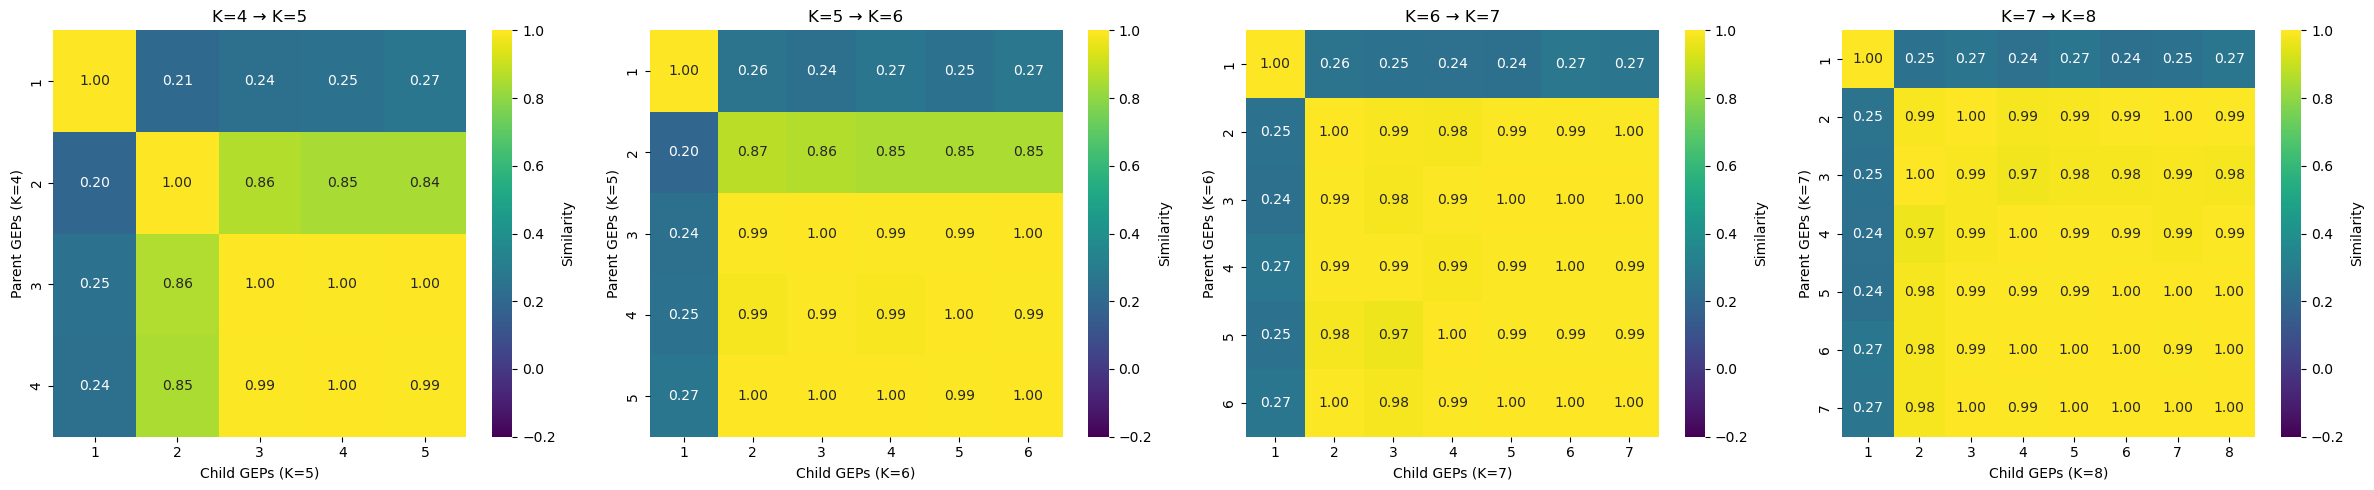

In [11]:
transitions_to_plot = list(all_sim_matrices.keys())[:4]

fig, axes = plt.subplots(1, len(transitions_to_plot),
                         figsize=(6 * len(transitions_to_plot), 5))
if len(transitions_to_plot) == 1:
    axes = [axes]

for ax, (k_p, k_c) in zip(axes, transitions_to_plot):
    sim = all_sim_matrices[(k_p, k_c)].astype(float)
    sns.heatmap(sim, cmap='viridis', annot=sim.shape[0] <= 12,
                fmt='.2f' if sim.shape[0] <= 12 else '',
                ax=ax, vmin=-0.2, vmax=1.0,
                cbar_kws={'label': 'Similarity'})
    ax.set_title(f'K={k_p} → K={k_c}', fontsize=12)
    ax.set_xlabel(f'Child GEPs (K={k_c})')
    ax.set_ylabel(f'Parent GEPs (K={k_p})')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "similarity_heatmaps.png"), dpi=150, bbox_inches='tight')
plt.show()

#### 7b. GEP Tree Diagram

A layered graph showing GEPs at each K level connected by parent→child edges. Nodes are colored by their top cell type.

In [12]:
# Color palette: tab20 for specific cell types, Set1 for family labels,
# gray reserved for "Ambiguous/Mixed" (each palette's own gray entry is excluded).

all_labels = set()
for k in k_values:
    for gep in all_nes[k].index:
        all_labels.add(assign_celltype(all_nes[k].loc[gep]))

family_labels = sorted([l for l in all_labels if is_family_label(l)])
specific_cts  = sorted([l for l in all_labels
                        if l != 'Ambiguous/Mixed' and not is_family_label(l)])

# tab20 for specific cell types, skipping the two gray entries (indices 14, 15)
tab20_non_gray = [plt.cm.tab20(i) for i in range(20) if i not in (14, 15)]

# Set1 for family labels, skipping the gray entry (index 8)
set1_non_gray = [plt.cm.Set1(i) for i in range(9) if i != 8]

ct_colors = {
    ct: tab20_non_gray[i % len(tab20_non_gray)]
    for i, ct in enumerate(specific_cts)
}

if family_labels:
    for i, fam in enumerate(family_labels):
        ct_colors[fam] = set1_non_gray[i % len(set1_non_gray)]

if 'Ambiguous/Mixed' in all_labels:
    ct_colors['Ambiguous/Mixed'] = '#888888'

# Order for legend: specific cts first, then family labels, then ambiguous
all_celltypes = specific_cts + family_labels
if 'Ambiguous/Mixed' in all_labels:
    all_celltypes = all_celltypes + ['Ambiguous/Mixed']

print(f"Labels in tree: {len(all_celltypes)}")
print(f"  Specific cell types: {len(specific_cts)}")
for ct in specific_cts:
    print(f"    {ct}")
if family_labels:
    print(f"  Family labels:       {len(family_labels)}")
    for fl in family_labels:
        print(f"    {fl}")
if 'Ambiguous/Mixed' in all_labels:
    print(f"  Ambiguous/Mixed:     present")


Labels in tree: 9
  Specific cell types: 6
    DC_pDC
    Mac_SPP1
    Mast
    Mono_CD14_ID1
    Mono_CD14_THBS1
    Mono_CD16
  Family labels:       2
    DC_family
    Macrophage_family
  Ambiguous/Mixed:     present


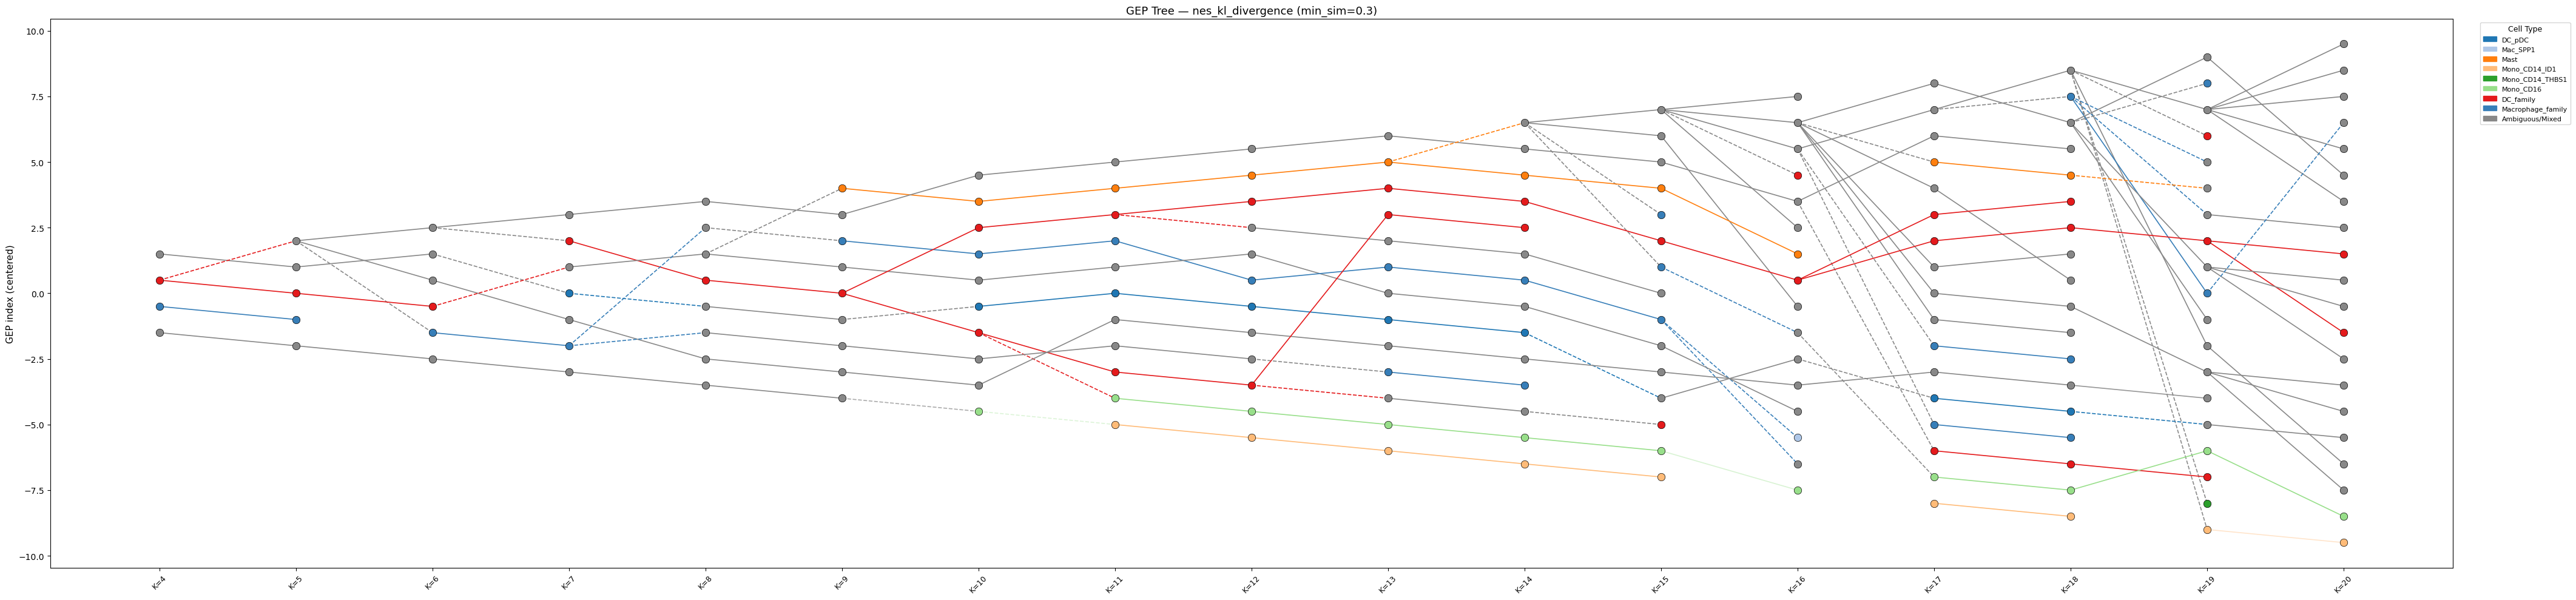

In [13]:
fig, ax = plt.subplots(figsize=(max(20, len(k_values) * 2.5), max(10, max(k_values) * 0.4)))

node_pos = {}
node_ct = {}

for xi, k in enumerate(k_values):
    n_geps = len(all_nes[k])
    for yi, gep in enumerate(all_nes[k].index):
        y = yi - (n_geps - 1) / 2
        node_pos[(k, gep)] = (xi, y)
        node_ct[(k, gep)] = assign_celltype(all_nes[k].loc[gep])

# Edge color = parent's cell type; solid line = cell type match, dashed = mismatch.
for _, row in edges_df[edges_df['parent_gep'].notna()].iterrows():
    p_key = (row['k_parent'], row['parent_gep'])
    c_key = (row['k_child'], row['child_gep'])
    if p_key in node_pos and c_key in node_pos:
        px, py = node_pos[p_key]
        cx, cy = node_pos[c_key]
        alpha = min(1.0, max(0.15, row['similarity']))
        color = ct_colors.get(row['parent_celltype'], 'black')
        ls = '-' if row['celltype_match'] else '--'
        ax.plot([px, cx], [py, cy], color=color, alpha=alpha, lw=1.2, ls=ls, zorder=1)

# Draw nodes, colored by assigned cell type
for (k, gep), (x, y) in node_pos.items():
    ct = node_ct[(k, gep)]
    color = ct_colors.get(ct, 'black')
    ax.scatter(x, y, c=[color], s=80, edgecolors='black', linewidths=0.5, zorder=2)

ax.set_xticks(range(len(k_values)))
ax.set_xticklabels([f'K={k}' for k in k_values], fontsize=9, rotation=45)
ax.set_ylabel('GEP index (centered)', fontsize=11)
ax.set_title(f'GEP Tree — {SIMILARITY_METRIC} (min_sim={MIN_SIMILARITY})', fontsize=13)

patches = [mpatches.Patch(color=ct_colors[ct], label=ct) for ct in all_celltypes]
ax.legend(handles=patches, loc='upper left', bbox_to_anchor=(1.01, 1.0),
          fontsize=8, title='Cell Type', title_fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gep_tree_diagram.png"), dpi=150, bbox_inches='tight')
plt.show()


#### 7c. Cell Type Composition Across K Values

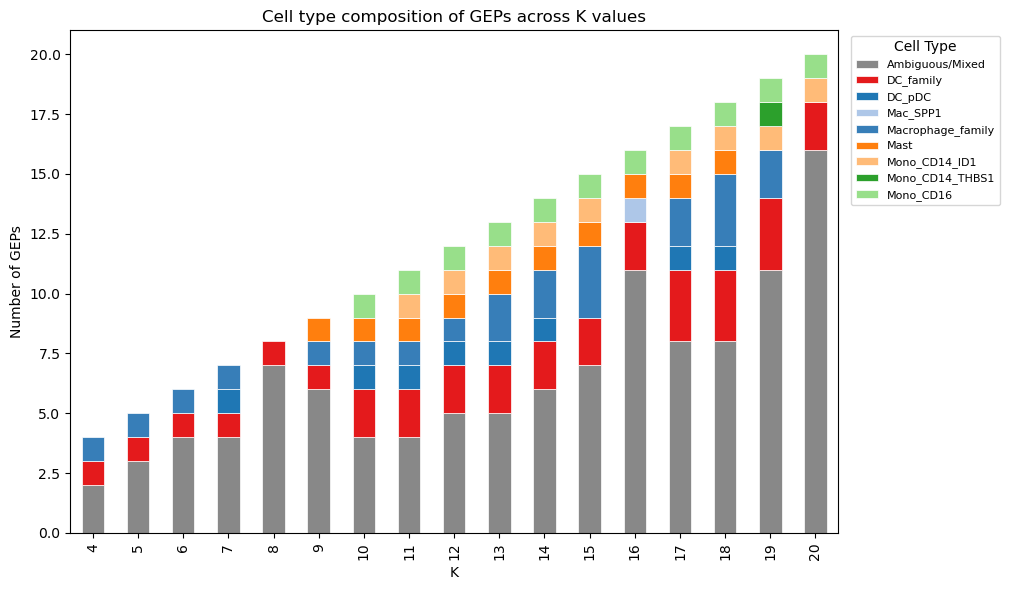

In [14]:
composition = []
for k in k_values:
    for gep in all_nes[k].index:
        ct = assign_celltype(all_nes[k].loc[gep])
        composition.append({'K': k, 'CellType': ct})

comp_df = pd.DataFrame(composition)
comp_pivot = comp_df.groupby(['K', 'CellType']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(max(10, len(k_values) * 0.6), 6))
comp_pivot.plot(kind='bar', stacked=True, ax=ax,
                color=[ct_colors.get(ct, 'gray') for ct in comp_pivot.columns],
                edgecolor='white', linewidth=0.5)
ax.set_xlabel('K')
ax.set_ylabel('Number of GEPs')
ax.set_title('Cell type composition of GEPs across K values')
ax.legend(bbox_to_anchor=(1.01, 1.0), fontsize=8, title='Cell Type')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "celltype_composition_by_k.png"), dpi=150, bbox_inches='tight')
plt.show()

#### 8. Save Pairwise Results

In [15]:
details_path = os.path.join(OUTPUT_DIR, "pairwise_similarities.csv")
details_df.to_csv(details_path, index=False)
print(f"Saved detailed pairwise similarities: {details_path}")
print(f"Shape: {details_df.shape}")
details_df.head()

Saved detailed pairwise similarities: hnc_1000hvg-percelltype_clanp_results/k4-20_corr-tree_kl-divergence/pairwise_similarities.csv
Shape: (2640, 9)


,k_parent,k_child,parent_gep,child_gep,similarity,raw_value,parent_celltype,child_celltype,celltype_match
0,4,5,1,1,0.998973,0.002055,Ambiguous/Mixed,Ambiguous/Mixed,True
1,4,5,1,2,0.207711,3.143214,Ambiguous/Mixed,Macrophage_family,False
2,4,5,1,3,0.237329,2.876614,Ambiguous/Mixed,DC_family,False
3,4,5,1,4,0.246443,2.801252,Ambiguous/Mixed,Ambiguous/Mixed,True
4,4,5,1,5,0.272900,2.597301,Ambiguous/Mixed,Ambiguous/Mixed,True


#### 9. Per-Transition Summary Table

In [16]:
transition_summary = []

for (k_p, k_c) in sorted(all_sim_matrices.keys()):
    subset = edges_df[(edges_df['k_parent'] == k_p) & (edges_df['k_child'] == k_c)]
    connected = subset[subset['parent_gep'].notna()]
    novel = subset[subset['parent_gep'].isna()]

    if len(connected) > 0:
        parent_counts = connected['parent_gep'].value_counts()
        n_splits = (parent_counts > 1).sum()
    else:
        n_splits = 0

    transition_summary.append({
        'transition': f'K={k_p}→{k_c}',
        'n_parents': len(all_nes[k_p]),
        'n_children': len(all_nes[k_c]),
        'n_edges': len(connected),
        'n_novel': len(novel),
        'n_splits': n_splits,
        'pct_same_ct': f"{100 * connected['celltype_match'].mean():.0f}%" if len(connected) > 0 else 'N/A',
        'mean_sim': f"{connected['similarity'].mean():.3f}" if len(connected) > 0 else 'N/A'
    })

tsummary_df = pd.DataFrame(transition_summary)
tsummary_df.to_csv(os.path.join(OUTPUT_DIR, "transition_summary.csv"), index=False)
print(tsummary_df.to_string(index=False))

transition  n_parents  n_children  n_edges  n_novel  n_splits pct_same_ct mean_sim
     K=4→5          4           5        5        0         1         80%    0.999
     K=5→6          5           6        6        0         1         83%    0.998
     K=6→7          6           7        7        0         1         57%    0.998
     K=7→8          7           8        8        0         1         62%    0.999
     K=8→9          8           9        9        0         1         78%    0.999
    K=9→10          9          10       10        0         1         80%    0.970
   K=10→11         10          11       11        0         1         82%    0.936
   K=11→12         11          12       12        0         1         92%    1.000
   K=12→13         12          13       13        0         1         85%    1.000
   K=13→14         13          14       14        0         1         93%    1.000
   K=14→15         14          15       15        0         1         73%    1.000
   K

#### 10. GEP NES Score Distributions at a Sample K

For each GEP at K=`K_VIZ`, plot its NES profile across all cell types (top row) and the derived probability distribution used for KL gating (bottom row). The assigned cell type is highlighted; others are gray.


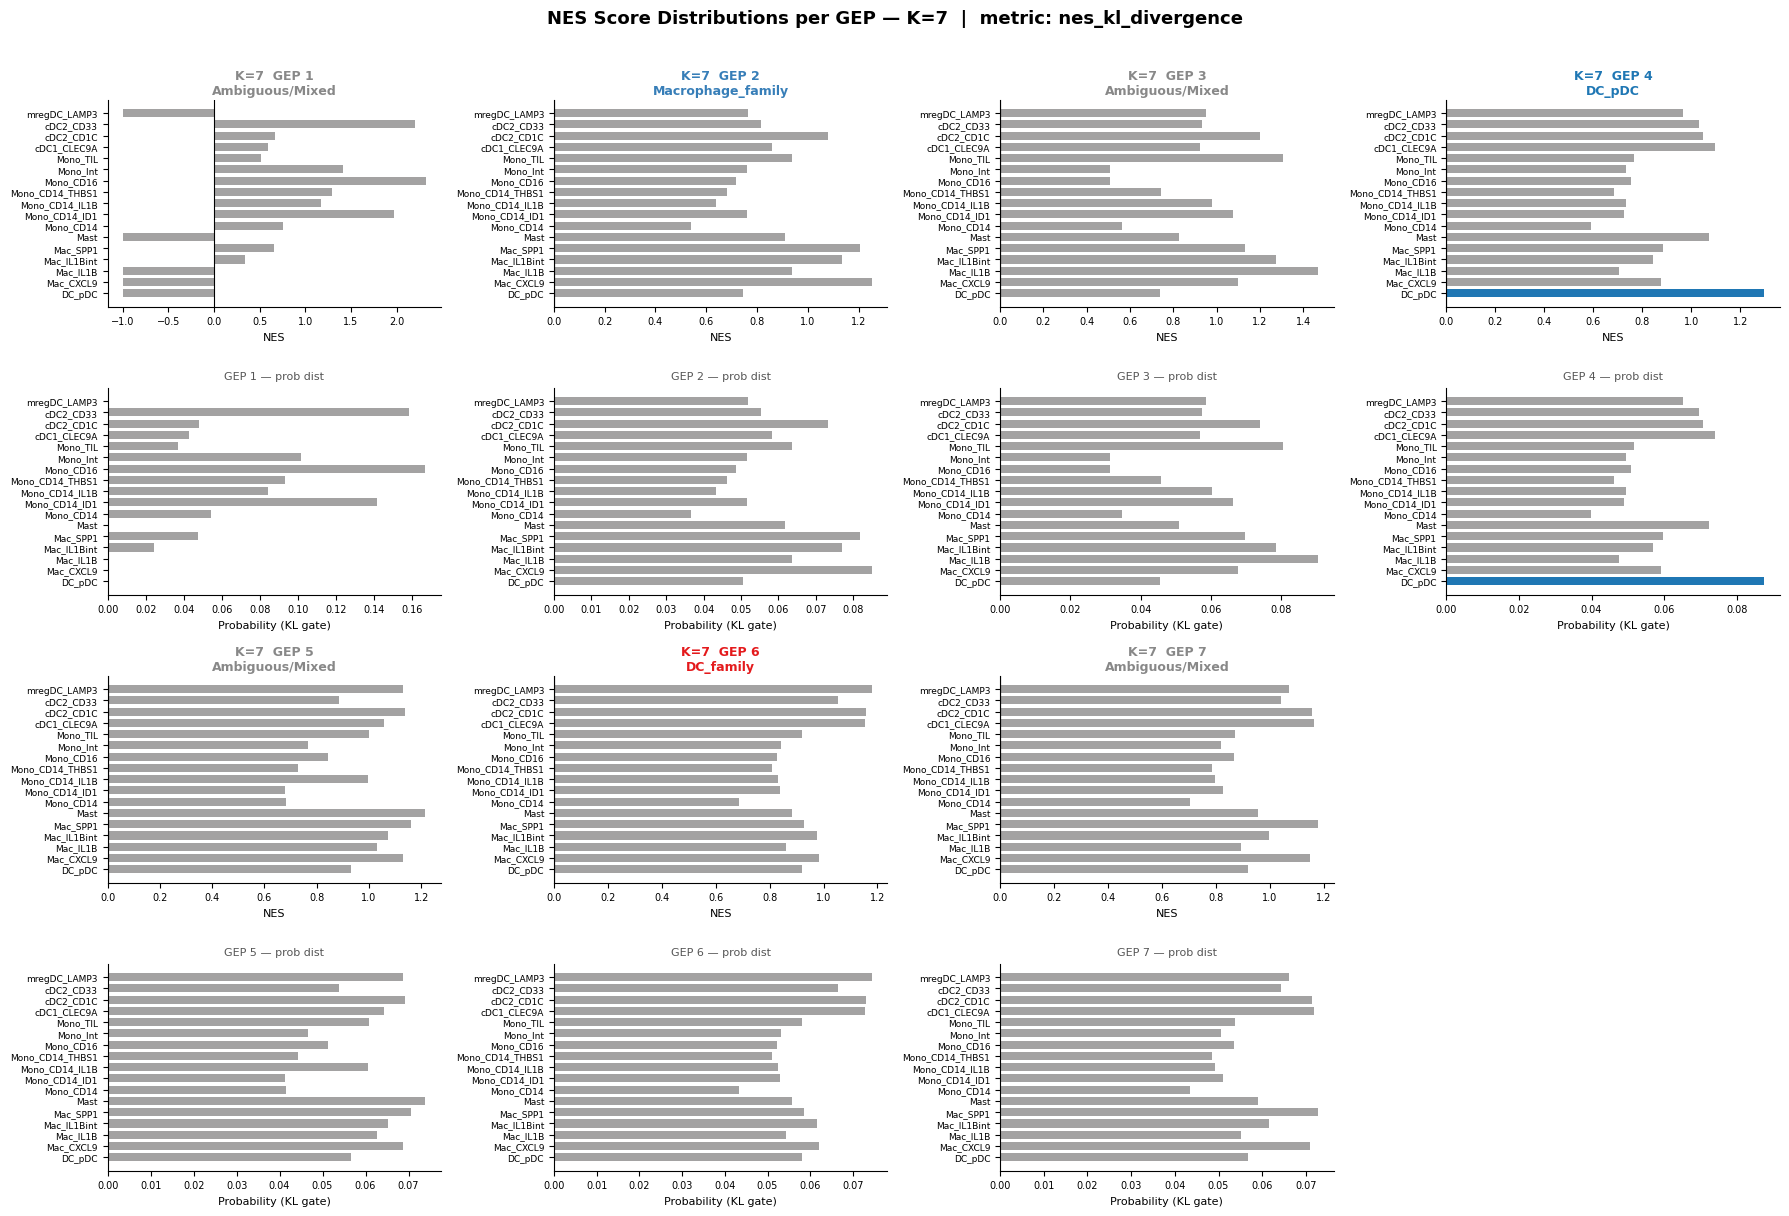

In [17]:
K_VIZ = 7
SHOW_PROB_DIST = True      # Set False to show only NES bars (no probability row)

nes_k = all_nes[K_VIZ]
n_geps = len(nes_k)
cell_types = nes_k.columns.tolist()

n_cols = min(4, n_geps)
n_rows_geps = int(np.ceil(n_geps / n_cols))
panel_rows = 2 if SHOW_PROB_DIST else 1   # NES row + optional prob-dist row

fig, axes = plt.subplots(
    n_rows_geps * panel_rows, n_cols,
    figsize=(n_cols * 4.5, n_rows_geps * panel_rows * 3.0),
    squeeze=False
)

for idx, gep in enumerate(nes_k.index):
    row_block = (idx // n_cols) * panel_rows   # first row of this GEP's block
    col       = idx % n_cols

    nes_row   = nes_k.loc[gep]
    ct_label  = assign_celltype(nes_row)
    prob_dist = nes_to_distribution(nes_row)   # ReLU-normalized, for KL gating
    node_color = ct_colors.get(ct_label, '#888888')

    # highlight the assigned cell type, gray out the rest
    bar_colors = [
        node_color if ct == ct_label else "#a3a2a2"
        for ct in cell_types
    ]
    y_pos = range(len(cell_types))

    # top panel: raw NES scores
    ax_nes = axes[row_block][col]
    ax_nes.barh(y_pos, nes_row.values, color=bar_colors, edgecolor='none', height=0.72)
    ax_nes.axvline(0, color='black', lw=0.8)
    ax_nes.set_yticks(y_pos)
    ax_nes.set_yticklabels(cell_types, fontsize=6.5)
    ax_nes.set_xlabel('NES', fontsize=8)
    ax_nes.set_title(
        f'K={K_VIZ}  GEP {gep}\n{ct_label}',
        fontsize=9, color=node_color, fontweight='bold', pad=4
    )
    ax_nes.tick_params(axis='x', labelsize=7)
    ax_nes.spines[['top', 'right']].set_visible(False)

    # bottom panel: probability distribution used for KL gating
    if SHOW_PROB_DIST:
        ax_prob = axes[row_block + 1][col]
        ax_prob.barh(y_pos, prob_dist, color=bar_colors, edgecolor='none', height=0.72)
        ax_prob.set_yticks(y_pos)
        ax_prob.set_yticklabels(cell_types, fontsize=6.5)
        ax_prob.set_xlabel('Probability (KL gate)', fontsize=8)
        ax_prob.set_title(f'GEP {gep} — prob dist', fontsize=8, color='#555555')
        ax_prob.tick_params(axis='x', labelsize=7)
        ax_prob.spines[['top', 'right']].set_visible(False)

# hide unused subplot slots
for idx in range(n_geps, n_rows_geps * n_cols):
    row_block = (idx // n_cols) * panel_rows
    col = idx % n_cols
    for pr in range(panel_rows):
        axes[row_block + pr][col].set_visible(False)

plt.suptitle(
    f'NES Score Distributions per GEP — K={K_VIZ}  |  metric: {SIMILARITY_METRIC}',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


#### 11. Landscape Statistics Across K

How the program landscape decomposes as K grows, without prescribing a single K:
- **11.1** Program persistence — how many consecutive K each lineage survives
- **11.2** Emergence order — smallest K at which each cell type first appears as a top assignment
- **11.3** Ambiguity & program-per-celltype trajectories


#### 11.1 Program Persistence via Connected Components

A **lineage** is a weakly connected component of the GEP tree. `consecutive_span` (longest contiguous K-run within a lineage) is the primary persistence score — stricter than `k_span`, which can be inflated by a lineage disappearing and reappearing.

Higher persistence = a more robust, resolution-independent program.


In [18]:
# build the directed tree graph
G = nx.DiGraph()
for k in k_values:
    for gep in all_nes[k].index:
        ct = assign_celltype(all_nes[k].loc[gep])
        G.add_node((k, gep), k=k, gep=gep, celltype=ct)

connected_edges_only = edges_df[edges_df['parent_gep'].notna()]
for _, row in connected_edges_only.iterrows():
    G.add_edge(
        (row['k_parent'], row['parent_gep']),
        (row['k_child'],  row['child_gep']),
        similarity=row['similarity']
    )

def longest_consecutive_run(ks_sorted):
    """Length of the largest contiguous integer run in a sorted list."""
    if not ks_sorted:
        return 0
    longest = current = 1
    for i in range(1, len(ks_sorted)):
        if ks_sorted[i] == ks_sorted[i-1] + 1:
            current += 1
            longest = max(longest, current)
        else:
            current = 1
    return longest

# weakly connected components = lineages
wcc = list(nx.weakly_connected_components(G))

per_lineage_records = []
per_gep_records = []
for lid, nodes in enumerate(wcc):
    ks_unique  = sorted(set(n[0] for n in nodes))
    k_span     = max(ks_unique) - min(ks_unique) + 1
    consec_span = longest_consecutive_run(ks_unique)
    cts = [G.nodes[n]['celltype'] for n in nodes]
    ct_counts = Counter(cts)
    dom_ct, dom_ct_n = ct_counts.most_common(1)[0]

    per_lineage_records.append({
        'lineage_id': lid,
        'n_nodes': len(nodes),
        'k_min': min(ks_unique),
        'k_max': max(ks_unique),
        'k_span': k_span,
        'consecutive_span': consec_span,
        'dominant_celltype': dom_ct,
        'celltype_purity': round(dom_ct_n / len(nodes), 3),
    })
    for n in nodes:
        per_gep_records.append({
            'k': n[0],
            'gep': n[1],
            'celltype': G.nodes[n]['celltype'],
            'lineage_id': lid,
            'lineage_k_span': k_span,
            'lineage_consecutive_span': consec_span,
            'lineage_size': len(nodes),
            'lineage_dominant_celltype': dom_ct,
        })

lineage_df = pd.DataFrame(per_lineage_records).sort_values(
    'consecutive_span', ascending=False).reset_index(drop=True)
gep_persistence_df = pd.DataFrame(per_gep_records)

lineage_df.to_csv(os.path.join(OUTPUT_DIR, 'lineage_persistence.csv'), index=False)
gep_persistence_df.to_csv(os.path.join(OUTPUT_DIR, 'gep_persistence.csv'), index=False)

print(f"Total lineages (weakly connected components): {len(lineage_df)}")
print(f"\nLineage persistence summary (consecutive K span):")
print(lineage_df['consecutive_span'].describe().round(2))
print(f"\nTop 15 most persistent lineages:")
print(lineage_df.head(15).to_string(index=False))


Total lineages (weakly connected components): 5

Lineage persistence summary (consecutive K span):
count     5.00
mean     10.00
std       7.58
min       2.00
25%       2.00
50%      12.00
75%      17.00
max      17.00
Name: consecutive_span, dtype: float64

Top 15 most persistent lineages:
 lineage_id  n_nodes  k_min  k_max  k_span  consecutive_span dominant_celltype  celltype_purity
          2      171      4     20      17                17   Ambiguous/Mixed            0.561
          3       17      4     20      17                17   Ambiguous/Mixed            0.529
          0       12      4     15      12                12   Ambiguous/Mixed            0.500
          1        2      4      5       2                 2 Macrophage_family            1.000
          4        2     17     18       2                 2     Mono_CD14_ID1            1.000


#### 11.2 Emergence Order per Cell Type

The smallest K at which each cell type first appears as a top (non-ambiguous) assignment. Cell types emerging at low K separate first (coarse biology); those appearing only at high K reflect finer sub-state structure. Cell types that never reach top-assignment are listed separately.


In [19]:
emergence = {}      # ct -> first K
last_seen = {}      # ct -> last K
k_presence = {}     # ct -> set of K values where ct is a top assignment

# track family-level emergence separately (e.g. when a Monocyte_family bundle first appears)
family_emergence = {}   # family_label -> first K
family_last_seen = {}   # family_label -> last K
family_k_presence = {}  # family_label -> set of K

for k in k_values:
    nes_k = all_nes[k]
    for gep in nes_k.index:
        ct = assign_celltype(nes_k.loc[gep])
        if ct == 'Ambiguous/Mixed':
            continue
        if is_family_label(ct):
            family_k_presence.setdefault(ct, set()).add(k)
            if ct not in family_emergence:
                family_emergence[ct] = k
            family_last_seen[ct] = k
            continue
        # Specific cell type
        k_presence.setdefault(ct, set()).add(k)
        if ct not in emergence:
            emergence[ct] = k
        last_seen[ct] = k

emergence_df = pd.DataFrame([
    {'celltype': ct,
     'first_K':   emergence[ct],
     'last_K':    last_seen[ct],
     'K_span':    last_seen[ct] - emergence[ct] + 1,
     'n_K_present': len(k_presence[ct])}
    for ct in emergence
]).sort_values('first_K').reset_index(drop=True)

annotated_cts = set()
for k in k_values:
    annotated_cts.update(all_nes[k].columns)
never_captured = sorted(annotated_cts - set(emergence.keys()))

# emergence_order.csv is intentionally not saved.

print("Emergence span per cell type (first_K → last_K as top assignment):")
print(emergence_df.to_string(index=False))
if never_captured:
    print(f"\nCell types never captured as top assignment in K=[{K_MIN},{K_MAX}]:")
    for ct in never_captured:
        print(f"  {ct}")

# Report family-level emergence separately
if family_emergence:
    fam_emergence_df = pd.DataFrame([
        {'family_label': fl,
         'first_K':      family_emergence[fl],
         'last_K':       family_last_seen[fl],
         'K_span':       family_last_seen[fl] - family_emergence[fl] + 1,
         'n_K_present':  len(family_k_presence[fl])}
        for fl in family_emergence
    ]).sort_values('first_K').reset_index(drop=True)
    # emergence_order_family.csv is intentionally not saved.
    print(f"\nEmergence span per FAMILY label (first_K → last_K):")
    print(fam_emergence_df.to_string(index=False))


Emergence span per cell type (first_K → last_K as top assignment):
       celltype  first_K  last_K  K_span  n_K_present
         DC_pDC        7      18      12            8
           Mast        9      18      10           10
      Mono_CD16       10      20      11           11
  Mono_CD14_ID1       11      20      10            9
       Mac_SPP1       16      16       1            1
Mono_CD14_THBS1       19      19       1            1

Cell types never captured as top assignment in K=[4,20]:
  Mac_CXCL9
  Mac_IL1B
  Mac_IL1Bint
  Mono_CD14
  Mono_CD14_IL1B
  Mono_Int
  Mono_TIL
  cDC1_CLEC9A
  cDC2_CD1C
  cDC2_CD33
  mregDC_LAMP3

Emergence span per FAMILY label (first_K → last_K):
     family_label  first_K  last_K  K_span  n_K_present
Macrophage_family        4      19      16           14
        DC_family        4      20      17           17


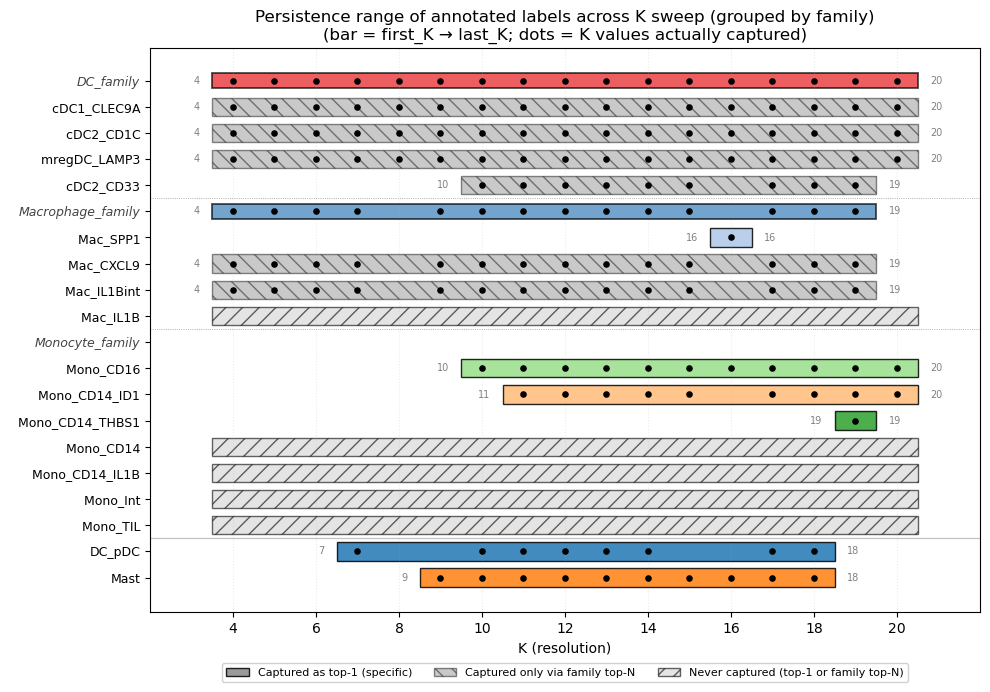

In [20]:
# Persistence diagram grouped by family. Each family shows: the family-level
# label row, then its members split into emerged (top-1), family-only
# (captured via top-N but never top-1), and never-captured. Cell types with
# no family go in an "Unaffiliated" block at the bottom.

# a cell type is "family-only captured" at K if it appears in a family
# label's top-N at K but never wins top-1 outright anywhere in the sweep
family_only_presence = {}   # ct -> sorted list of K values (family top-N only)

if CELLTYPE_FAMILIES and 'family_label_df' in globals() and len(family_label_df) > 0:
    top_n_cols = [c for c in ['top1_celltype', 'top2_celltype', 'top3_celltype']
                  if c in family_label_df.columns]
    for ct in never_captured:
        ks_via_family = set()
        for col in top_n_cols:
            ks_via_family.update(
                family_label_df.loc[family_label_df[col] == ct, 'k']
                               .astype(int).tolist()
            )
        if ks_via_family:
            family_only_presence[ct] = sorted(ks_via_family)

# cell types that are still truly absent (no top-1, no family top-N)
truly_never = [ct for ct in never_captured if ct not in family_only_presence]

# map specific cts to families + identify unaffiliated cts
affiliated_cts = set()
if CELLTYPE_FAMILIES:
    for fam_cts in CELLTYPE_FAMILIES.values():
        affiliated_cts.update(fam_cts)

# build family groups
family_groups = []
if CELLTYPE_FAMILIES:
    for fam_name, fam_cts in CELLTYPE_FAMILIES.items():
        fam_label = f"{fam_name}{FAMILY_LABEL_SUFFIX}"
        fam_row = None
        if fam_label in family_emergence:
            fam_row = {
                'label':      fam_label,
                'first_K':    family_emergence[fam_label],
                'last_K':     family_last_seen[fam_label],
                'present_ks': sorted(family_k_presence[fam_label]),
            }
        members_emerged = (
            emergence_df[emergence_df['celltype'].isin(fam_cts)]
            .sort_values('first_K')
            .to_dict('records')
        )
        # split family-only captured (soft) from truly never (hatched gray)
        members_family_only = [
            {'celltype': ct,
             'first_K':  family_only_presence[ct][0],
             'last_K':   family_only_presence[ct][-1],
             'present_ks': family_only_presence[ct]}
            for ct in fam_cts if ct in family_only_presence
        ]
        members_family_only.sort(key=lambda m: m['first_K'])
        members_never = [ct for ct in fam_cts if ct in truly_never]

        if fam_row or members_emerged or members_family_only or members_never:
            candidate_ks = []
            if fam_row is not None:
                candidate_ks.append(fam_row['first_K'])
            if members_emerged:
                candidate_ks.append(min(m['first_K'] for m in members_emerged))
            if members_family_only:
                candidate_ks.append(min(m['first_K'] for m in members_family_only))
            sort_key = min(candidate_ks) if candidate_ks else K_MAX + 1
            family_groups.append({
                'sort_key':            sort_key,
                'fam_name':            fam_name,
                'fam_label':           fam_label,
                'fam_row':             fam_row,
                'members_emerged':     members_emerged,
                'members_family_only': members_family_only,
                'members_never':       members_never,
            })
    family_groups.sort(key=lambda g: g['sort_key'])

# unaffiliated specific cts (not a member of any family)
unaffil_emerged = (
    emergence_df[~emergence_df['celltype'].isin(affiliated_cts)]
    .sort_values('first_K')
    .to_dict('records')
)
unaffil_never = [ct for ct in truly_never if ct not in affiliated_cts]

# total rows (each family contributes 1 header + members)
n_rows = sum(
    1 + len(g['members_emerged']) + len(g['members_family_only']) + len(g['members_never'])
    for g in family_groups
) + len(unaffil_emerged) + len(unaffil_never)

fig, ax = plt.subplots(figsize=(10, max(3, n_rows * 0.35)))

# row-plotting helpers (capture shared state via closures)
y_positions = []
y_labels = []
family_label_row_ys = set()
family_group_ends = []

def _plot_specific(y, row, indent=False):
    color = ct_colors.get(row['celltype'], '#888888')
    ax.barh(y, row['last_K'] - row['first_K'] + 1,
            left=row['first_K'] - 0.5,
            color=color, edgecolor='black', height=0.7, alpha=0.85)
    present_ks = sorted(k_presence[row['celltype']])
    ax.scatter(present_ks, [y] * len(present_ks),
               s=14, color='black', zorder=3)
    ax.text(row['first_K'] - 0.8, y, f"{row['first_K']}",
            va='center', ha='right', fontsize=7, color='gray')
    ax.text(row['last_K'] + 0.8, y, f"{row['last_K']}",
            va='center', ha='left',  fontsize=7, color='gray')
    label = ('  ' + row['celltype']) if indent else row['celltype']
    y_positions.append(y); y_labels.append(label)

def _plot_family_only(y, row, indent=False):
    """Captured via family top-N only (never top-1); drawn with lower alpha + hatch."""
    color = ct_colors.get(row['celltype'], '#888888')
    ax.barh(y, row['last_K'] - row['first_K'] + 1,
            left=row['first_K'] - 0.5,
            color=color, edgecolor='black', hatch='\\\\',
            height=0.7, alpha=0.45)
    ax.scatter(row['present_ks'], [y] * len(row['present_ks']),
               s=14, color='black', zorder=3)
    ax.text(row['first_K'] - 0.8, y, f"{row['first_K']}",
            va='center', ha='right', fontsize=7, color='gray')
    ax.text(row['last_K'] + 0.8, y, f"{row['last_K']}",
            va='center', ha='left',  fontsize=7, color='gray')
    label = ('  ' + row['celltype']) if indent else row['celltype']
    y_positions.append(y); y_labels.append(label)

def _plot_never(y, ct, indent=False):
    ax.barh(y, K_MAX - K_MIN + 1, left=K_MIN - 0.5,
            color='lightgray', edgecolor='black', hatch='//',
            height=0.7, alpha=0.6)
    label = ('  ' + ct) if indent else ct
    y_positions.append(y); y_labels.append(label)

def _plot_family(y, fam_row):
    color = ct_colors.get(fam_row['label'], '#888888')
    ax.barh(y, fam_row['last_K'] - fam_row['first_K'] + 1,
            left=fam_row['first_K'] - 0.5,
            color=color, edgecolor='black', linewidth=1.3,
            height=0.55, alpha=0.70)
    ax.scatter(fam_row['present_ks'], [y] * len(fam_row['present_ks']),
               s=14, color='black', zorder=3)
    ax.text(fam_row['first_K'] - 0.8, y, f"{fam_row['first_K']}",
            va='center', ha='right', fontsize=7, color='gray')
    ax.text(fam_row['last_K'] + 0.8, y, f"{fam_row['last_K']}",
            va='center', ha='left',  fontsize=7, color='gray')
    y_positions.append(y); y_labels.append(fam_row['label'])
    family_label_row_ys.add(y)

def _plot_family_header_only(y, fam_label):
    # no bar; italic label only, for families whose family-level label never emerged
    y_positions.append(y); y_labels.append(fam_label)
    family_label_row_ys.add(y)

# draw family groups
y = 0
for g in family_groups:
    if g['fam_row'] is not None:
        _plot_family(y, g['fam_row'])
    else:
        _plot_family_header_only(y, g['fam_label'])
    y += 1
    for m in g['members_emerged']:
        _plot_specific(y, m, indent=True); y += 1
    for m in g['members_family_only']:
        _plot_family_only(y, m, indent=True); y += 1
    for ct in g['members_never']:
        _plot_never(y, ct, indent=True); y += 1
    family_group_ends.append(y - 0.5)

# unaffiliated specific cell types
unaffil_start_y = y
for m in unaffil_emerged:
    _plot_specific(y, m, indent=False); y += 1
for ct in unaffil_never:
    _plot_never(y, ct, indent=False); y += 1

# dividers between family groups / unaffiliated block
for yd in family_group_ends[:-1]:
    ax.axhline(yd, color='dimgray', lw=0.6, ls=':', alpha=0.7)
if family_groups and (unaffil_emerged or unaffil_never):
    ax.axhline(unaffil_start_y - 0.5,
               color='dimgray', lw=0.9, ls='-', alpha=0.4)

# legend for the three capture states
legend_handles = [
    mpatches.Patch(facecolor='#888888', edgecolor='black', alpha=0.85,
                   label='Captured as top-1 (specific)'),
    mpatches.Patch(facecolor='#888888', edgecolor='black', alpha=0.45,
                   hatch='\\\\', label='Captured only via family top-N'),
    mpatches.Patch(facecolor='lightgray', edgecolor='black', alpha=0.6,
                   hatch='//', label='Never captured (top-1 or family top-N)'),
]
ax.legend(handles=legend_handles, loc='upper center',
          bbox_to_anchor=(0.5, -0.08), fontsize=8,
          framealpha=0.9, ncol=3)

# axes, labels, etc.
ax.set_yticks(y_positions)
ticklabels = ax.set_yticklabels(y_labels, fontsize=9)
for pos, lbl in zip(y_positions, ticklabels):
    if pos in family_label_row_ys:
        lbl.set_style('italic')
        lbl.set_color('#444444')
ax.invert_yaxis()

ax.set_xlabel('K (resolution)')
title = ('Persistence range of annotated labels across K sweep')
if family_groups:
    title += ' (grouped by family)'
ax.set_title(title + '\n(bar = first_K → last_K; '
                     'dots = K values actually captured)')
ax.set_xlim(K_MIN - 2, K_MAX + 2)
ax.set_xticks(range(K_MIN, K_MAX + 1, 2))
ax.grid(axis='x', alpha=0.25, linestyle=':')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'emergence_span.png'),
            dpi=150, bbox_inches='tight')
plt.show()


#### 11.3 Ambiguity Rate and Program-per-CellType Trajectories

- **Ambiguity rate(K)** — fraction of GEPs at K with no dominant cell type (top-2 too close, per `AMBIGUITY_THRESHOLD`)
- **Programs-per-cell-type(K)** — GEPs assigned to each cell type at each K; flat = homogeneous, rising = heterogeneous


In [21]:
traj_records = []
for k in k_values:
    nes_k = all_nes[k]
    assignments = [assign_celltype(nes_k.loc[gep]) for gep in nes_k.index]
    n_total = len(assignments)
    n_amb     = sum(1 for ct in assignments if ct == 'Ambiguous/Mixed')
    n_family  = sum(1 for ct in assignments if is_family_label(ct))
    n_specific = n_total - n_amb - n_family
    unique_cts = set(assignments) - {'Ambiguous/Mixed'} - {c for c in assignments if is_family_label(c)}
    traj_records.append({
        'K': k,
        'n_total_GEPs': n_total,
        'n_ambiguous': n_amb,
        'n_family_level': n_family,
        'n_celltype_specific': n_specific,
        'ambiguity_rate':      n_amb     / n_total if n_total else 0.0,
        'family_level_rate':   n_family  / n_total if n_total else 0.0,
        'celltype_specific_rate': n_specific / n_total if n_total else 0.0,
        'n_unique_celltypes_covered': len(unique_cts),
    })
traj_df = pd.DataFrame(traj_records)

ppc_records = []
for k in k_values:
    nes_k = all_nes[k]
    cts = [assign_celltype(nes_k.loc[gep]) for gep in nes_k.index]
    for ct, n in Counter(cts).items():
        ppc_records.append({'K': k, 'celltype': ct, 'n_GEPs': n})
ppc_df = pd.DataFrame(ppc_records)
ppc_pivot = (ppc_df.pivot_table(index='K', columns='celltype',
                                values='n_GEPs', fill_value=0)
             .reindex(k_values, fill_value=0))

traj_df.to_csv(os.path.join(OUTPUT_DIR, 'landscape_trajectories.csv'), index=False)
ppc_pivot.to_csv(os.path.join(OUTPUT_DIR, 'program_per_celltype_trajectory.csv'))

print("Landscape trajectory summary:")
print(traj_df.to_string(index=False))
if traj_df['n_family_level'].sum() > 0:
    print(f"\nFamily-level resolution recovered {int(traj_df['n_family_level'].sum())} "
          f"GEPs that would otherwise be labeled Ambiguous/Mixed.")

Landscape trajectory summary:
 K  n_total_GEPs  n_ambiguous  n_family_level  n_celltype_specific  ambiguity_rate  family_level_rate  celltype_specific_rate  n_unique_celltypes_covered
 4             4            2               2                    0        0.500000           0.500000                0.000000                           0
 5             5            3               2                    0        0.600000           0.400000                0.000000                           0
 6             6            4               2                    0        0.666667           0.333333                0.000000                           0
 7             7            4               2                    1        0.571429           0.285714                0.142857                           1
 8             8            7               1                    0        0.875000           0.125000                0.000000                           0
 9             9            6               2 

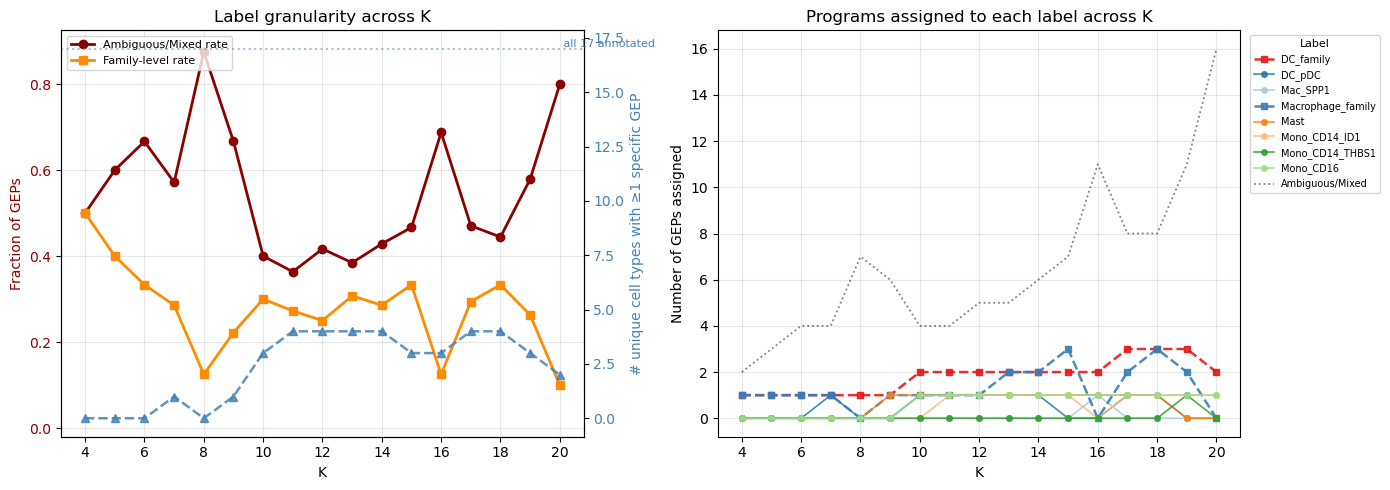

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: ambiguity / family-level / coverage across K
ax = axes[0]
ax.plot(traj_df['K'], traj_df['ambiguity_rate'], 'o-',
        color='darkred', lw=2, markersize=6, label='Ambiguous/Mixed rate')
if traj_df['n_family_level'].sum() > 0:
    ax.plot(traj_df['K'], traj_df['family_level_rate'], 's-',
            color='darkorange', lw=2, markersize=6,
            label='Family-level rate')
ax.set_xlabel('K')
ax.set_ylabel('Fraction of GEPs', color='darkred')
ax.tick_params(axis='y', labelcolor='darkred')
max_rate = max(0.5,
               traj_df['ambiguity_rate'].max() + 0.05,
               traj_df['family_level_rate'].max() + 0.05)
ax.set_ylim(-0.02, max_rate)
ax.grid(alpha=0.3)
ax.set_title('Label granularity across K')
ax.legend(loc='upper left', fontsize=8)

ax2 = ax.twinx()
ax2.plot(traj_df['K'], traj_df['n_unique_celltypes_covered'], '^--',
         color='steelblue', lw=1.8, markersize=6, alpha=0.85,
         label='Unique cell types covered')
ax2.set_ylabel('# unique cell types with ≥1 specific GEP',
               color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2.axhline(len(annotated_cts), color='steelblue', ls=':', alpha=0.5)
ax2.text(k_values[-1], len(annotated_cts), f' all {len(annotated_cts)} annotated',
         color='steelblue', va='bottom', fontsize=8)

# right: program-per-cell-type trajectories
ax = axes[1]
for ct in ppc_pivot.columns:
    if ct == 'Ambiguous/Mixed':
        continue
    if is_family_label(ct):
        # family labels: thicker, dashed, to stand out
        ax.plot(ppc_pivot.index, ppc_pivot[ct], 's--',
                color=ct_colors.get(ct, '#888888'), lw=1.8, markersize=5,
                label=ct, alpha=0.9)
    else:
        ax.plot(ppc_pivot.index, ppc_pivot[ct], 'o-',
                color=ct_colors.get(ct, '#888888'), lw=1.2, markersize=4,
                label=ct, alpha=0.85)
# ambiguous as dashed black
if 'Ambiguous/Mixed' in ppc_pivot.columns:
    ax.plot(ppc_pivot.index, ppc_pivot['Ambiguous/Mixed'], ':',
            color='black', lw=1.3, alpha=0.5, label='Ambiguous/Mixed')
ax.set_xlabel('K')
ax.set_ylabel('Number of GEPs assigned')
ax.set_title('Programs assigned to each label across K')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7,
          title='Label', title_fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'landscape_trajectories.png'),
            dpi=150, bbox_inches='tight')
plt.show()


#### 12. Annotation Granularity Diagnostics

Whether the annotated cell types form a coherent family hierarchy:
- **12.1** Between-cell-type redundancy — median Pearson R between NES columns across K; high R = two labels fire on the same programs
- **12.2** Family coherence — within- vs. between-family R, if `CELLTYPE_FAMILIES` is set


#### 12.1 Between-cell-type Redundancy Matrix

In [23]:
all_cts_sorted = sorted(set().union(*[df.columns for df in all_nes.values()]))

per_k_corr = {}
for k in k_values:
    nes = all_nes[k].astype(float)
    if nes.shape[0] >= 3:                   # need ≥3 GEPs for meaningful correlation
        per_k_corr[k] = nes.corr(method='pearson')

# median aggregation across K
median_corr = pd.DataFrame(index=all_cts_sorted, columns=all_cts_sorted,
                           dtype=float)
for A in all_cts_sorted:
    for B in all_cts_sorted:
        vals = [c.loc[A, B] for c in per_k_corr.values()
                if A in c.index and B in c.columns
                and not np.isnan(c.loc[A, B])]
        if vals:
            median_corr.loc[A, B] = np.median(vals)

# diagonal = 1 (self-correlation)
for ct in median_corr.index:
    median_corr.at[ct, ct] = 1.0
# drop cell types that never co-appear (all-NaN row/col)
median_corr = (median_corr.dropna(how='all')
                          .dropna(axis=1, how='all')
                          .fillna(0))

median_corr.to_csv(os.path.join(OUTPUT_DIR, 'celltype_redundancy_matrix.csv'))
print(f"Redundancy matrix shape: {median_corr.shape}")
print(f"Number of K values contributing: {len(per_k_corr)}")


Redundancy matrix shape: (17, 17)
Number of K values contributing: 17


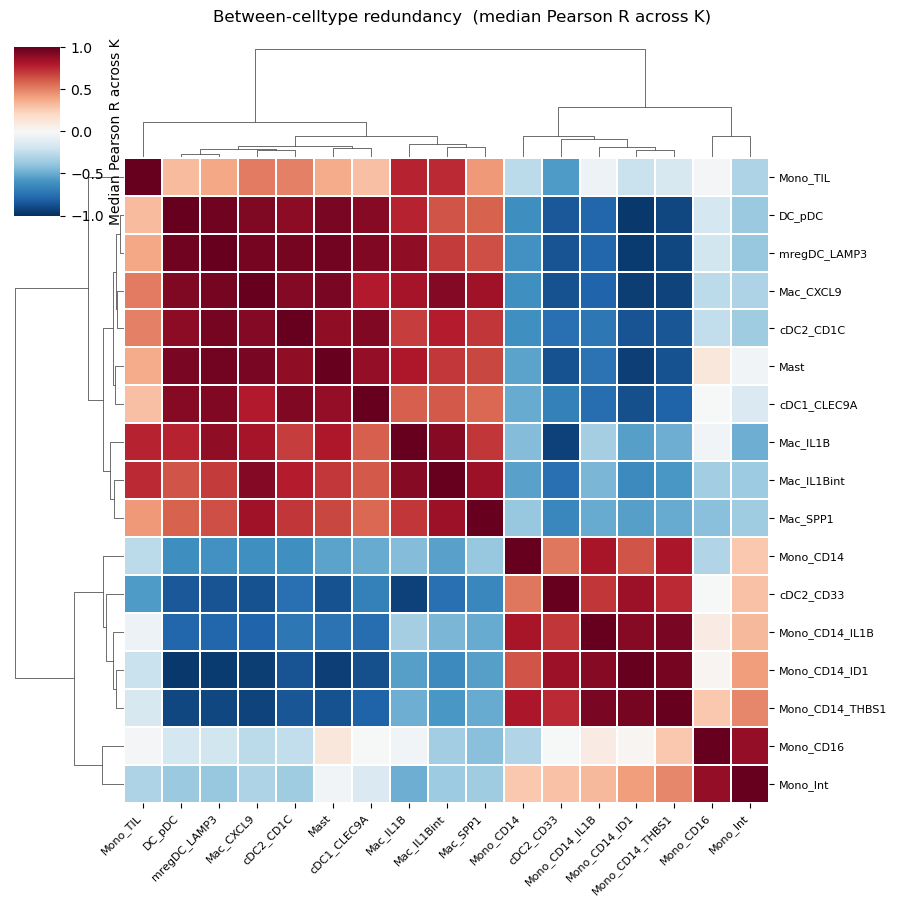

In [24]:
g = sns.clustermap(
    median_corr,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    method='average', metric='euclidean',
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Median Pearson R across K'},
    figsize=(max(8, len(median_corr) * 0.55),
             max(8, len(median_corr) * 0.55)),
    dendrogram_ratio=0.15,
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xmajorticklabels(), rotation=45, ha='right', fontsize=8)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_ymajorticklabels(), rotation=0, fontsize=8)
g.fig.suptitle('Between-celltype redundancy  (median Pearson R across K)',
               y=1.02, fontsize=12)
plt.savefig(os.path.join(OUTPUT_DIR, 'celltype_redundancy_clustermap.png'),
            dpi=150, bbox_inches='tight')
plt.show()


#### 12.2 Family Coherence Diagnostic

Partitions the §12.1 redundancy matrix into within-family and between-family pairs. A coherent family hierarchy shows high within-family R (members share programs) and low between-family R. Skipped when `CELLTYPE_FAMILIES is None`.


In [25]:
if CELLTYPE_FAMILIES is None:
    family_pair_df = None
    within_family_df = None
    between_family_df = None
else:
    ct_to_family = _build_ct_to_family(CELLTYPE_FAMILIES)

    # build all upper-triangle pairs directly from median_corr
    cts_in_matrix = list(median_corr.index)
    pair_rows = []
    for i, A in enumerate(cts_in_matrix):
        for B in cts_in_matrix[i + 1:]:
            pair_rows.append({
                'celltype_A': A,
                'celltype_B': B,
                'median_R_across_K': median_corr.loc[A, B],
            })
    mc = pd.DataFrame(pair_rows)

    mc["family_A"] = mc["celltype_A"].map(ct_to_family)
    mc["family_B"] = mc["celltype_B"].map(ct_to_family)

    def _classify(row):
        if pd.isna(row["family_A"]) or pd.isna(row["family_B"]):
            return "unassigned"
        if row["family_A"] == row["family_B"]:
            return "within"
        return "between"

    mc["pair_type"] = mc.apply(_classify, axis=1)

    def _pair_label(row):
        fa, fb = row["family_A"], row["family_B"]
        if pd.isna(fa) or pd.isna(fb):
            return None
        a, b = sorted([fa, fb])
        return f"{a} \u2194 {b}" if a != b else a

    mc["family_pair"] = mc.apply(_pair_label, axis=1)

    family_pair_df = mc.sort_values("median_R_across_K", ascending=False)
    family_pair_df.to_csv(
        os.path.join(OUTPUT_DIR, "family_coherence_pairs.csv"), index=False)

    # how coherent is each family?
    within = mc[mc["pair_type"] == "within"]
    if len(within) > 0:
        within_family_df = (within.groupby("family_A")
                            .agg(n_pairs=("median_R_across_K", "count"),
                                 median_within_R=("median_R_across_K", "median"),
                                 mean_within_R  =("median_R_across_K", "mean"),
                                 min_within_R   =("median_R_across_K", "min"),
                                 max_within_R   =("median_R_across_K", "max"))
                            .round(3)
                            .sort_values("median_within_R", ascending=False))
        within_family_df.index.name = "family"
        within_family_df.to_csv(
            os.path.join(OUTPUT_DIR, "family_coherence_within.csv"))
    else:
        within_family_df = pd.DataFrame()

    # which pairs of families look similar?
    between = mc[mc["pair_type"] == "between"]
    if len(between) > 0:
        between_family_df = (between.groupby("family_pair")
                             .agg(n_pairs=("median_R_across_K", "count"),
                                  median_between_R=("median_R_across_K", "median"),
                                  mean_between_R  =("median_R_across_K", "mean"),
                                  min_between_R   =("median_R_across_K", "min"),
                                  max_between_R   =("median_R_across_K", "max"))
                             .round(3)
                             .sort_values("median_between_R", ascending=False))
        between_family_df.to_csv(
            os.path.join(OUTPUT_DIR, "family_coherence_between.csv"))
    else:
        between_family_df = pd.DataFrame()


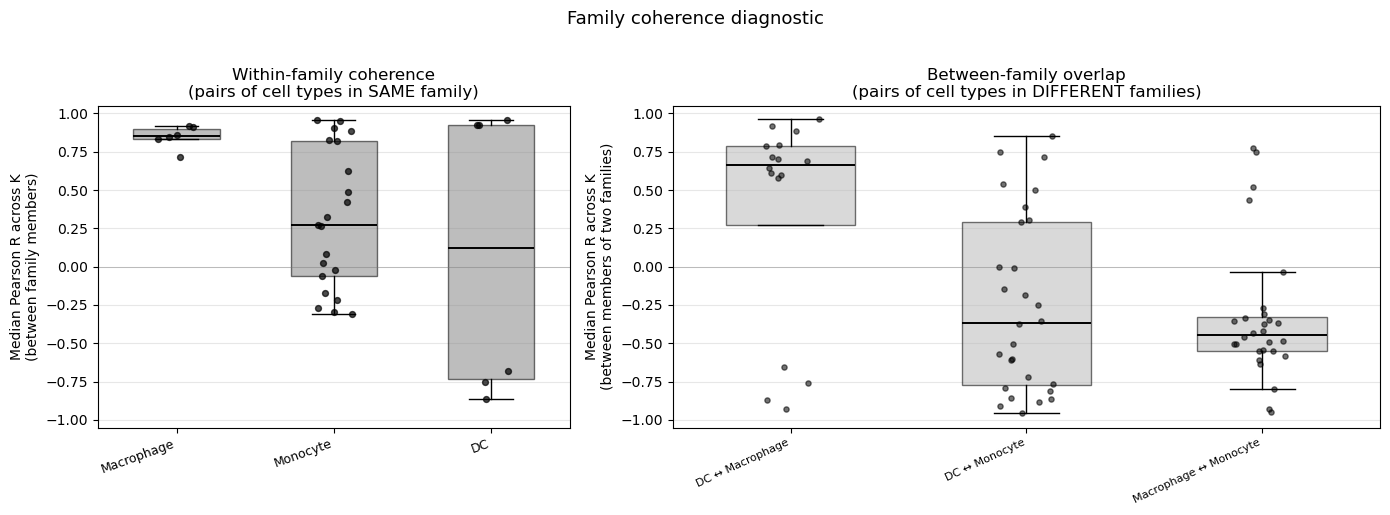

Saved → hnc_1000hvg-percelltype_clanp_results/k4-20_corr-tree_kl-divergence/family_coherence.png


In [26]:
if CELLTYPE_FAMILIES is None or family_pair_df is None:
    pass  # diagnostic was skipped
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                             gridspec_kw={"width_ratios": [1.2, 1.8]})

    # left: within-family boxplot (one box per family)
    ax = axes[0]
    within = family_pair_df[family_pair_df["pair_type"] == "within"]
    if len(within) > 0 and len(within_family_df) > 0:
        fam_order = within_family_df.index.tolist()
        data = [within[within["family_A"] == f]["median_R_across_K"].values
                for f in fam_order]
        bp = ax.boxplot(data, positions=range(len(fam_order)), widths=0.55,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color="black", lw=1.4))
        # tint each box using the color of one of the family's members
        for patch, fam in zip(bp["boxes"], fam_order):
            members = CELLTYPE_FAMILIES[fam]
            col = ct_colors.get(members[0], "#888888")
            patch.set_facecolor(col)
            patch.set_alpha(0.55)

        # overlay raw points
        for i, f in enumerate(fam_order):
            vals = within[within["family_A"] == f]["median_R_across_K"].values
            if len(vals) == 0:
                continue
            jit = np.random.uniform(-0.12, 0.12, size=len(vals))
            ax.scatter(np.full(len(vals), i) + jit, vals,
                       c="black", s=18, alpha=0.7, zorder=3)

        ax.set_xticks(range(len(fam_order)))
        ax.set_xticklabels(fam_order, rotation=20, ha="right", fontsize=9)
        ax.set_ylabel("Median Pearson R across K\n(between family members)")
        ax.set_title("Within-family coherence\n(pairs of cell types in SAME family)")
    else:
        ax.text(0.5, 0.5, "No within-family pairs\n(all singletons)",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title("Within-family coherence")

    ax.axhline(0, color="gray", lw=0.6, alpha=0.5)
    ax.set_ylim(-1.05, 1.05)
    ax.grid(axis="y", alpha=0.3)

    # right: between-family boxplot (one box per family pair)
    ax = axes[1]
    between = family_pair_df[family_pair_df["pair_type"] == "between"]
    if len(between) > 0 and len(between_family_df) > 0:
        pair_order = between_family_df.index.tolist()
        data = [between[between["family_pair"] == p]["median_R_across_K"].values
                for p in pair_order]
        bp = ax.boxplot(data, positions=range(len(pair_order)), widths=0.55,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color="black", lw=1.4))
        for patch in bp["boxes"]:
            patch.set_facecolor("#bbbbbb")
            patch.set_alpha(0.55)

        for i, p in enumerate(pair_order):
            vals = between[between["family_pair"] == p]["median_R_across_K"].values
            if len(vals) == 0:
                continue
            jit = np.random.uniform(-0.12, 0.12, size=len(vals))
            ax.scatter(np.full(len(vals), i) + jit, vals,
                       c="black", s=14, alpha=0.55, zorder=3)

        ax.set_xticks(range(len(pair_order)))
        ax.set_xticklabels(pair_order, rotation=25, ha="right", fontsize=8)
        ax.set_ylabel("Median Pearson R across K\n(between members of two families)")
        ax.set_title("Between-family overlap\n(pairs of cell types in DIFFERENT families)")
    else:
        ax.text(0.5, 0.5, "No between-family pairs",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title("Between-family overlap")

    ax.axhline(0, color="gray", lw=0.6, alpha=0.5)
    ax.set_ylim(-1.05, 1.05)
    ax.grid(axis="y", alpha=0.3)

    plt.suptitle("Family coherence diagnostic", fontsize=13, y=1.02)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, "family_coherence.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


#### 13. Joint Granularity Summary

Combines each cell type's emergence K (§11.2) with its best consecutive persistence (§11.1) into one table.


In [27]:
def longest_consecutive_interval(ks):
    """Return (length, start_K, end_K) for the longest contiguous K run."""
    ks = sorted(set(ks))
    if not ks:
        return None, None, None

    best_start = best_end = start = prev = ks[0]
    for k in ks[1:]:
        if k == prev + 1:
            prev = k
        else:
            if (prev - start) > (best_end - best_start):
                best_start, best_end = start, prev
            start = prev = k

    if (prev - start) > (best_end - best_start):
        best_start, best_end = start, prev

    return best_end - best_start + 1, best_start, best_end


# Direct exact-label presence at each K
ct_k_presence_expanded = {ct: set() for ct in annotated_cts}
for k in k_values:
    nes_k = all_nes[k]
    for gep in nes_k.index:
        ct = assign_celltype(nes_k.loc[gep])
        if ct in ct_k_presence_expanded:
            ct_k_presence_expanded[ct].add(k)

# Family-label proxy presence: count a K for a specific cell type when
# it appears in the top 3 under a family-level assignment.
if 'family_label_df' in globals() and len(family_label_df) > 0:
    top3_cols = [c for c in ['top1_celltype', 'top2_celltype', 'top3_celltype']
                 if c in family_label_df.columns]
    for _, row in family_label_df.iterrows():
        k = row['k']
        for col in top3_cols:
            ct = row.get(col)
            if pd.notna(ct) and ct in ct_k_presence_expanded:
                ct_k_presence_expanded[ct].add(k)

best_persistence = {}
best_persistence_start = {}
best_persistence_end = {}
for ct, ks in ct_k_presence_expanded.items():
    length, start_k, end_k = longest_consecutive_interval(ks)
    best_persistence[ct] = length
    best_persistence_start[ct] = start_k
    best_persistence_end[ct] = end_k

summary_rows = []
for ct in sorted(annotated_cts):
    # emergence
    first_K = emergence.get(ct, None)
    # best persistence
    best_pers = best_persistence.get(ct, None)
    best_pers_start = best_persistence_start.get(ct, None)
    best_pers_end = best_persistence_end.get(ct, None)
    summary_rows.append({
        'celltype': ct,
        'emerges_at_K': first_K,
        'best_consecutive_persistence': best_pers,
        'best_persistence_start_K': best_pers_start,
        'best_persistence_end_K': best_pers_end,
    })

joint_summary = pd.DataFrame(summary_rows).sort_values(
    ['emerges_at_K', 'celltype'], na_position='last')
joint_summary.to_csv(os.path.join(OUTPUT_DIR, 'joint_granularity_summary.csv'),
                     index=False)

print("Joint granularity summary (per annotated cell type):")
print("=" * 90)
print(joint_summary.to_string(index=False))
print("\nInterpretation:")
print("  - best_consecutive_persistence  → longest contiguous K run where the cell type is direct or in a family top-3")



Joint granularity summary (per annotated cell type):
       celltype  emerges_at_K  best_consecutive_persistence  best_persistence_start_K  best_persistence_end_K
         DC_pDC           7.0                           5.0                      10.0                    14.0
           Mast           9.0                          10.0                       9.0                    18.0
      Mono_CD16          10.0                          11.0                      10.0                    20.0
  Mono_CD14_ID1          11.0                           5.0                      11.0                    15.0
       Mac_SPP1          16.0                          11.0                       9.0                    19.0
Mono_CD14_THBS1          19.0                           1.0                      19.0                    19.0
      Mac_CXCL9           NaN                           7.0                       9.0                    15.0
       Mac_IL1B           NaN                           NaN        